# 02. Анализ основной воронки — исправленная версия

## Что исправлено

- добавлены более понятные графики;
- на графиках теперь показаны **все 5 шагов**, включая шаги с нулевыми потерями;
- над столбиками выводятся значения, поэтому не будет ощущения, что столбик «пропал»;
- добавлен готовый текстовый вывод по результатам анализа;
- добавлена отдельная таблица с интерпретацией относительных и абсолютных потерь.


In [16]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


In [17]:
DATA_PATH = Path('../data/raw')
OUTPUT_TABLES = Path('../outputs/tables')
OUTPUT_CHARTS = Path('../outputs/charts')

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_CHARTS.mkdir(parents=True, exist_ok=True)

sessions = pd.read_csv(DATA_PATH / 'sessions.csv')
events = pd.read_csv(DATA_PATH / 'events.csv')
orders = pd.read_csv(DATA_PATH / 'orders.csv')


In [18]:
sessions['start_time'] = pd.to_datetime(sessions['start_time'], errors='coerce')
events['timestamp'] = pd.to_datetime(events['timestamp'], errors='coerce')
orders['order_time'] = pd.to_datetime(orders['order_time'], errors='coerce')
events['event_type_norm'] = events['event_type'].astype(str).str.strip().str.lower()


## 1. Определение воронки

Воронка строится на уровне `session_id`.

Шаги:
1. `session`
2. `page_view`
3. `add_to_cart`
4. `checkout`
5. `purchase`

Сессия считается достигшей шага, если внутри нее было хотя бы одно событие соответствующего типа.


In [19]:
funnel_steps = ['page_view', 'add_to_cart', 'checkout', 'purchase']

session_flags = (
    events.assign(step_flag=1)
    .pivot_table(
        index='session_id',
        columns='event_type_norm',
        values='step_flag',
        aggfunc='max',
        fill_value=0
    )
    .reset_index()
)

for step in funnel_steps:
    if step not in session_flags.columns:
        session_flags[step] = 0

session_flags = session_flags[['session_id'] + funnel_steps]

funnel_base = (
    sessions[['session_id']]
    .drop_duplicates()
    .merge(session_flags, on='session_id', how='left')
    .fillna(0)
)

for step in funnel_steps:
    funnel_base[step] = funnel_base[step].astype(int)

funnel_base.head()


,session_id,page_view,add_to_cart,checkout,purchase
0,1,1,1,0,0
1,2,1,1,1,1
2,3,1,1,1,1
3,4,1,0,0,0
4,5,1,0,0,0


## 2. Основная таблица воронки


In [20]:
step_counts = {
    'session': funnel_base['session_id'].nunique(),
    'page_view': funnel_base['page_view'].sum(),
    'add_to_cart': funnel_base['add_to_cart'].sum(),
    'checkout': funnel_base['checkout'].sum(),
    'purchase': funnel_base['purchase'].sum()
}

funnel_df = pd.DataFrame({
    'step': list(step_counts.keys()),
    'sessions': list(step_counts.values())
})

funnel_df['conversion_from_prev'] = funnel_df['sessions'] / funnel_df['sessions'].shift(1)
funnel_df.loc[0, 'conversion_from_prev'] = 1.0

funnel_df['conversion_from_start'] = funnel_df['sessions'] / funnel_df.loc[0, 'sessions']

funnel_df['drop_from_prev_abs'] = funnel_df['sessions'].shift(1) - funnel_df['sessions']
funnel_df.loc[0, 'drop_from_prev_abs'] = 0

funnel_df['drop_from_prev_pct'] = 1 - funnel_df['conversion_from_prev']
funnel_df.loc[0, 'drop_from_prev_pct'] = 0

funnel_df


,step,sessions,conversion_from_prev,conversion_from_start,drop_from_prev_abs,drop_from_prev_pct
0,session,120000,1.0000,1.0000,0.0000,0.0000
1,page_view,120000,1.0000,1.0000,0.0000,0.0000
2,add_to_cart,81518,0.6793,0.6793,"38,482.0000",0.3207
3,checkout,44909,0.5509,0.3742,"36,609.0000",0.4491
4,purchase,33580,0.7477,0.2798,"11,329.0000",0.2523


## 3. Bottleneck-анализ

Здесь важно разделять:

- **относительные потери** — где самая низкая конверсия от предыдущего шага;
- **абсолютные потери** — где теряется больше всего сессий в штуках.


In [21]:
relative_bottleneck = funnel_df.loc[funnel_df['drop_from_prev_pct'].idxmax()]
absolute_bottleneck = funnel_df.loc[funnel_df['drop_from_prev_abs'].idxmax()]

summary_bottlenecks = pd.DataFrame([
    {
        'type': 'Максимальная относительная потеря',
        'step': relative_bottleneck['step'],
        'sessions': relative_bottleneck['sessions'],
        'conversion_from_prev': relative_bottleneck['conversion_from_prev'],
        'drop_from_prev_abs': relative_bottleneck['drop_from_prev_abs'],
        'drop_from_prev_pct': relative_bottleneck['drop_from_prev_pct'],
    },
    {
        'type': 'Максимальная абсолютная потеря',
        'step': absolute_bottleneck['step'],
        'sessions': absolute_bottleneck['sessions'],
        'conversion_from_prev': absolute_bottleneck['conversion_from_prev'],
        'drop_from_prev_abs': absolute_bottleneck['drop_from_prev_abs'],
        'drop_from_prev_pct': absolute_bottleneck['drop_from_prev_pct'],
    }
])

summary_bottlenecks


,type,step,sessions,conversion_from_prev,drop_from_prev_abs,drop_from_prev_pct
0,Максимальная относительная потеря,checkout,44909,0.5509,"36,609.0000",0.4491
1,Максимальная абсолютная потеря,add_to_cart,81518,0.6793,"38,482.0000",0.3207


In [22]:
overall_purchase_conversion = (
    funnel_df.loc[funnel_df['step'] == 'purchase', 'sessions'].iloc[0]
    / funnel_df.loc[funnel_df['step'] == 'session', 'sessions'].iloc[0]
)

cart_to_purchase_conversion = (
    funnel_df.loc[funnel_df['step'] == 'purchase', 'sessions'].iloc[0]
    / funnel_df.loc[funnel_df['step'] == 'add_to_cart', 'sessions'].iloc[0]
)

checkout_to_purchase_conversion = (
    funnel_df.loc[funnel_df['step'] == 'purchase', 'sessions'].iloc[0]
    / funnel_df.loc[funnel_df['step'] == 'checkout', 'sessions'].iloc[0]
)

print(f'Итоговая конверсия session → purchase: {overall_purchase_conversion:.2%}')
print(f'Конверсия add_to_cart → purchase: {cart_to_purchase_conversion:.2%}')
print(f'Конверсия checkout → purchase: {checkout_to_purchase_conversion:.2%}')


Итоговая конверсия session → purchase: 27.98%
Конверсия add_to_cart → purchase: 41.19%
Конверсия checkout → purchase: 74.77%


## 4. Графики

В этой версии графики построены так, чтобы были явно видны **все шаги**, даже если потери на каком-то шаге равны нулю.


In [23]:
def add_value_labels(ax, values, fmt_func):
    y_max = max(values) if len(values) else 0
    offset = y_max * 0.015 if y_max > 0 else 0.02
    for i, v in enumerate(values):
        ax.text(i, v + offset, fmt_func(v), ha='center', va='bottom')


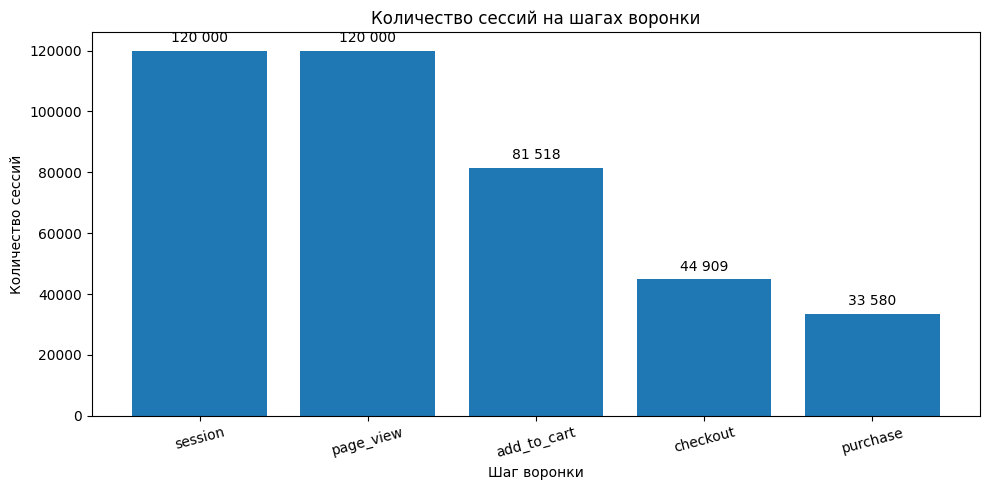

In [24]:
plt.figure(figsize=(10, 5))
ax = plt.gca()
ax.bar(funnel_df['step'], funnel_df['sessions'])
ax.set_title('Количество сессий на шагах воронки')
ax.set_xlabel('Шаг воронки')
ax.set_ylabel('Количество сессий')
plt.xticks(rotation=15)
add_value_labels(ax, funnel_df['sessions'].tolist(), lambda v: f'{int(v):,}'.replace(',', ' '))
plt.tight_layout()
plt.savefig(OUTPUT_CHARTS / 'main_funnel_sessions_fixed.png', bbox_inches='tight')
plt.show()


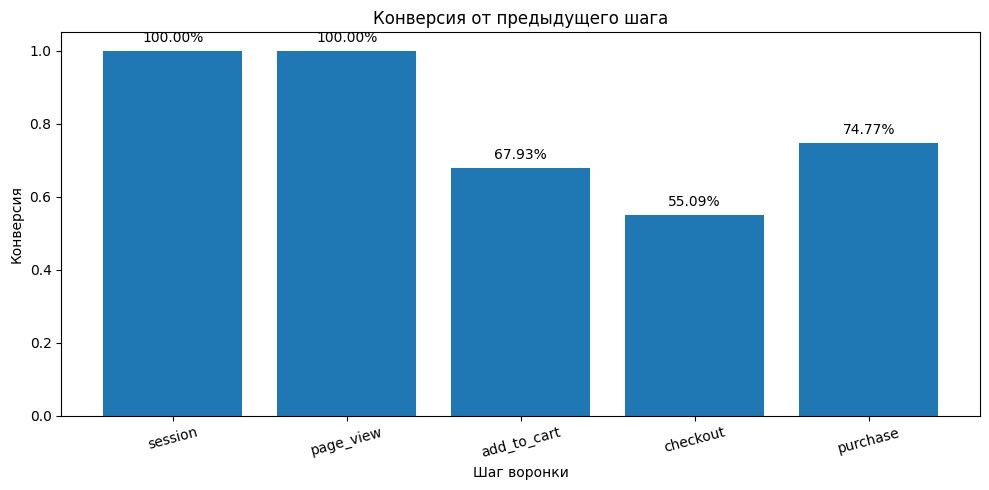

In [25]:
plt.figure(figsize=(10, 5))
ax = plt.gca()
ax.bar(funnel_df['step'], funnel_df['conversion_from_prev'])
ax.set_title('Конверсия от предыдущего шага')
ax.set_xlabel('Шаг воронки')
ax.set_ylabel('Конверсия')
plt.xticks(rotation=15)
add_value_labels(ax, funnel_df['conversion_from_prev'].tolist(), lambda v: f'{v:.2%}')
plt.tight_layout()
plt.savefig(OUTPUT_CHARTS / 'conversion_from_prev_fixed.png', bbox_inches='tight')
plt.show()


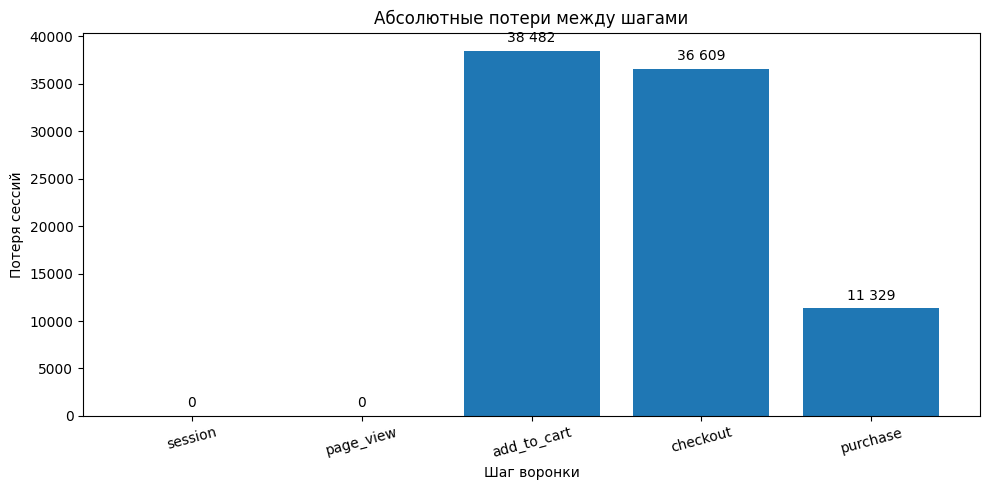

In [26]:
plt.figure(figsize=(10, 5))
ax = plt.gca()
ax.bar(funnel_df['step'], funnel_df['drop_from_prev_abs'])
ax.set_title('Абсолютные потери между шагами')
ax.set_xlabel('Шаг воронки')
ax.set_ylabel('Потеря сессий')
plt.xticks(rotation=15)
add_value_labels(ax, funnel_df['drop_from_prev_abs'].tolist(), lambda v: f'{int(v):,}'.replace(',', ' '))
plt.tight_layout()
plt.savefig(OUTPUT_CHARTS / 'drop_from_prev_abs_fixed.png', bbox_inches='tight')
plt.show()


## 5. Отдельная таблица интерпретации шагов


In [27]:
step_interpretation = pd.DataFrame({
    'step': funnel_df['step'],
    'sessions': funnel_df['sessions'],
    'conversion_from_prev': funnel_df['conversion_from_prev'],
    'drop_from_prev_abs': funnel_df['drop_from_prev_abs'],
    'drop_from_prev_pct': funnel_df['drop_from_prev_pct'],
    'product_meaning': [
        'База анализа: все сессии',
        'Пользователь дошел до просмотра товара',
        'Пользователь проявил явный интерес и добавил товар в корзину',
        'Пользователь начал оформление заказа',
        'Пользователь завершил покупку'
    ]
})

step_interpretation


,step,sessions,conversion_from_prev,drop_from_prev_abs,drop_from_prev_pct,product_meaning
0,session,120000,1.0000,0.0000,0.0000,База анализа: все сессии
1,page_view,120000,1.0000,0.0000,0.0000,Пользователь дошел до просмотра товара
2,add_to_cart,81518,0.6793,"38,482.0000",0.3207,Пользователь проявил явный интерес и добавил т...
3,checkout,44909,0.5509,"36,609.0000",0.4491,Пользователь начал оформление заказа
4,purchase,33580,0.7477,"11,329.0000",0.2523,Пользователь завершил покупку


## 6. Сверка с таблицей заказов


In [28]:
purchase_sessions = funnel_base['purchase'].sum()
orders_cnt = orders['order_id'].nunique()

comparison = pd.DataFrame({
    'metric': ['purchase sessions from events', 'orders from orders table'],
    'value': [purchase_sessions, orders_cnt]
})

comparison


,metric,value
0,purchase sessions from events,33580
1,orders from orders table,33580


## 7. Автоматически сформированный текстовый вывод

Этот блок можно потом почти без изменений перенести в README или в `case_summary.md`.


In [29]:
relative_step = relative_bottleneck['step']
absolute_step = absolute_bottleneck['step']
relative_loss_pct = relative_bottleneck['drop_from_prev_pct']
absolute_loss_abs = int(absolute_bottleneck['drop_from_prev_abs'])

conclusion_text = f'''
Вывод по основной воронке
------------------------
Итоговая конверсия из сессии в покупку составила {overall_purchase_conversion:.2%}.

Наибольшая относительная потеря наблюдается на шаге {relative_step}: здесь теряется {relative_loss_pct:.2%} сессий по отношению к предыдущему этапу.

Наибольшая абсолютная потеря наблюдается на шаге {absolute_step}: здесь продукт теряет {absolute_loss_abs:,} сессий.'''.replace(',', ' ')

conclusion_text += '''

Это означает, что относительные и абсолютные потери не обязательно совпадают.
С продуктовой точки зрения это важно: один этап может быть самым слабым по конверсии,
а другой — самым дорогим для бизнеса в штуках.

Предварительная гипотеза: проблема сосредоточена не в финальной оплате, а раньше —
на этапе принятия решения о добавлении товара в корзину и/или переходе к оформлению.
Поэтому следующим шагом нужен сегментный анализ по устройствам, источникам трафика,
типу пользователя, категориям и ценовым сегментам.
'''

print(conclusion_text)



Вывод по основной воронке
------------------------
Итоговая конверсия из сессии в покупку составила 27.98%.

Наибольшая относительная потеря наблюдается на шаге checkout: здесь теряется 44.91% сессий по отношению к предыдущему этапу.

Наибольшая абсолютная потеря наблюдается на шаге add_to_cart: здесь продукт теряет 38 482 сессий.

Это означает, что относительные и абсолютные потери не обязательно совпадают.
С продуктовой точки зрения это важно: один этап может быть самым слабым по конверсии,
а другой — самым дорогим для бизнеса в штуках.

Предварительная гипотеза: проблема сосредоточена не в финальной оплате, а раньше —
на этапе принятия решения о добавлении товара в корзину и/или переходе к оформлению.
Поэтому следующим шагом нужен сегментный анализ по устройствам, источникам трафика,
типу пользователя, категориям и ценовым сегментам.



## 8. Сохранение результатов


In [30]:
funnel_df.to_csv(OUTPUT_TABLES / 'main_funnel_fixed.csv', index=False)
summary_bottlenecks.to_csv(OUTPUT_TABLES / 'bottlenecks_summary.csv', index=False)
step_interpretation.to_csv(OUTPUT_TABLES / 'step_interpretation.csv', index=False)
comparison.to_csv(OUTPUT_TABLES / 'purchase_orders_comparison_fixed.csv', index=False)

print('Таблицы сохранены:')
print('-', OUTPUT_TABLES / 'main_funnel_fixed.csv')
print('-', OUTPUT_TABLES / 'bottlenecks_summary.csv')
print('-', OUTPUT_TABLES / 'step_interpretation.csv')
print('-', OUTPUT_TABLES / 'purchase_orders_comparison_fixed.csv')


Таблицы сохранены:
- ../outputs/tables/main_funnel_fixed.csv
- ../outputs/tables/bottlenecks_summary.csv
- ../outputs/tables/step_interpretation.csv
- ../outputs/tables/purchase_orders_comparison_fixed.csv
